In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import make_moons
X,y = make_moons(n_samples=100,noise=0.25,random_state=3)

print("="*50)
print("半月形数据集信息")
print("="*50)
print(f"特征数据形状：{X.shape}")
print(f"标签形状：{y.shape}")
print(f"标签唯一值：{np.unique(y)}")

X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,random_state=42)

print(f"训练集大小：{X_train.shape[0]}个样本")
print(f"测试集大小：{X_test.shape[0]}个样本")

半月形数据集信息
特征数据形状：(100, 2)
标签形状：(100,)
标签唯一值：[0 1]
训练集大小：75个样本
测试集大小：25个样本


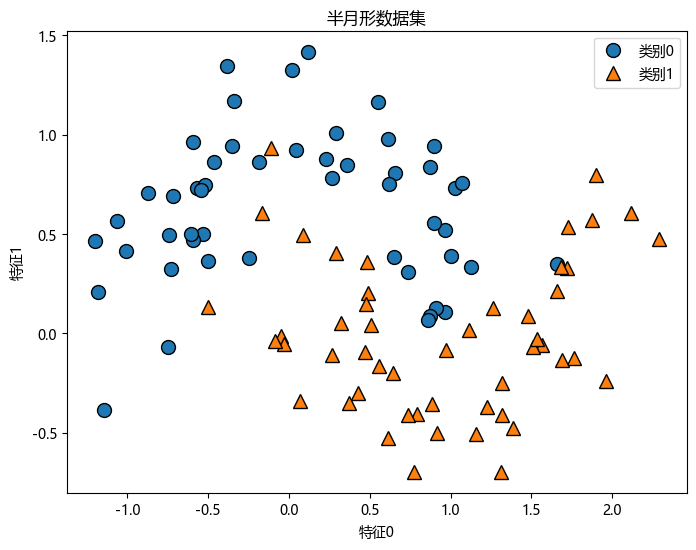

In [2]:
plt.figure(figsize=(8,6))
mglearn.discrete_scatter(X[:,0],X[:,1],y)

plt.xlabel("特征0")
plt.ylabel("特征1")
plt.legend(["类别0","类别1"],loc="best")
plt.title("半月形数据集")
plt.show()

In [4]:
mlp = MLPClassifier(solver='lbfgs',random_state=0)
mlp.fit(X_train,y_train)

train_score = mlp.score(X_train,y_train)
test_score = mlp.score(X_test,y_test)

print("="*50)
print("神经网络")
print("="*50)
print(f"训练集准确率：{train_score:.3f}")
print(f"测试集准确率：{test_score:.3f}")

神经网络
训练集准确率：1.000
测试集准确率：0.880


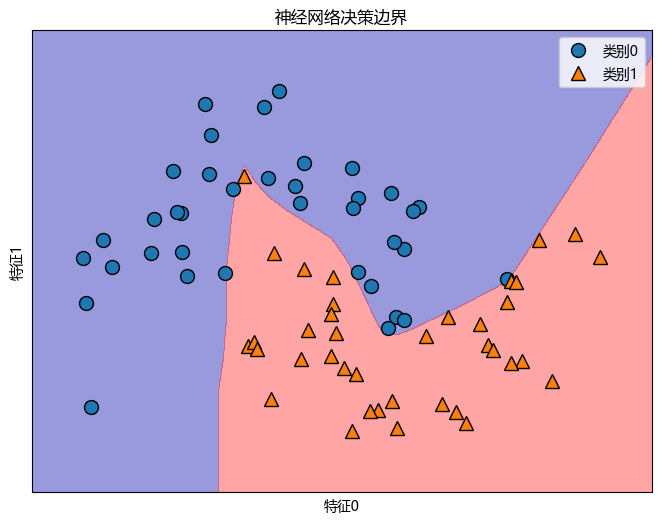

In [5]:
plt.figure(figsize=(8,6))
mglearn.plots.plot_2d_separator(mlp,X_train,fill=True,alpha=0.4)
mglearn.discrete_scatter(X_train[:,0],X_train[:,1],y_train)
plt.title("神经网络决策边界")
plt.xlabel("特征0")
plt.ylabel("特征1")
plt.legend(["类别0","类别1"],loc="best")
plt.show()

In [1]:
mlp_small = MLPClassifier(solver='lbfgs',random_state=0,hidden_layer_sizes=[10])
mlp_small.fit(X_train,y_train)

print("="*50)
print("神经网络(10个隐藏神经元)")
print("="*50)
print(f"训练集准确率：{mlp_small.score(X_train,y_train):.3f}")
print(f"测试集准确率：{mlp_small.score(X_test,y_test):.3f}")

plt.figure(figsize=(8,6))
mglearn.plots.plot_2d_separator(mlp_small,X_train,fill=True,alpha=0.4)
mglearn.discrete_scatter(X_train[:,0],X_train[:,1],y_train)
plt.title("神经网络决策边界")
plt.xlabel("特征0")
plt.ylabel("特征1")
plt.legend(["类别0","类别1"],loc="best")
plt.show()

NameError: name 'MLPClassifier' is not defined

神经网络（两个隐藏层，每层10个神经元）
训练集准确率：0.987
测试集准确率：0.840


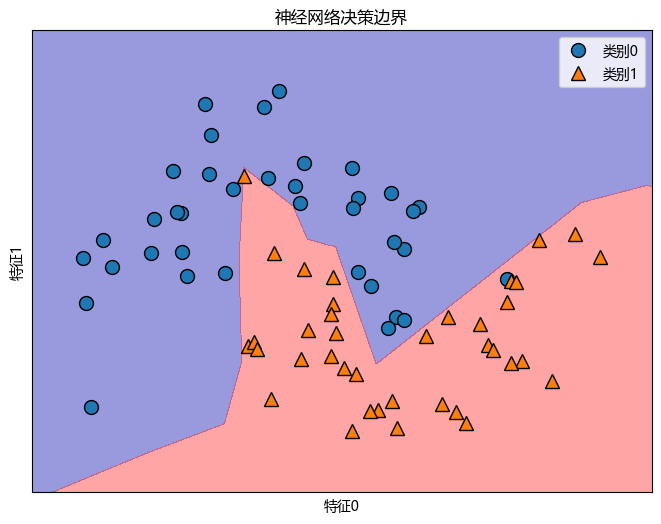

In [8]:
mlp_two_layers = MLPClassifier(solver='lbfgs',random_state=0,hidden_layer_sizes=[10,10])
mlp_two_layers.fit(X_train,y_train)
print("="*50)
print("神经网络（两个隐藏层，每层10个神经元）")
print("="*50)
print(f"训练集准确率：{mlp_two_layers.score(X_train,y_train):.3f}")
print(f"测试集准确率：{mlp_two_layers.score(X_test,y_test):.3f}")

plt.figure(figsize=(8,6))
mglearn.plots.plot_2d_separator(mlp_two_layers,X_train,fill=True,alpha=0.4)
mglearn.discrete_scatter(X_train[:,0],X_train[:,1],y_train)
plt.title("神经网络决策边界")
plt.xlabel("特征0")
plt.ylabel("特征1")
plt.legend(["类别0","类别1"],loc="best")
plt.show()

不同激活函数的对比
tanh激活函数 - 测试集准确率：0.840
relu激活函数 - 测试集准确率：0.840


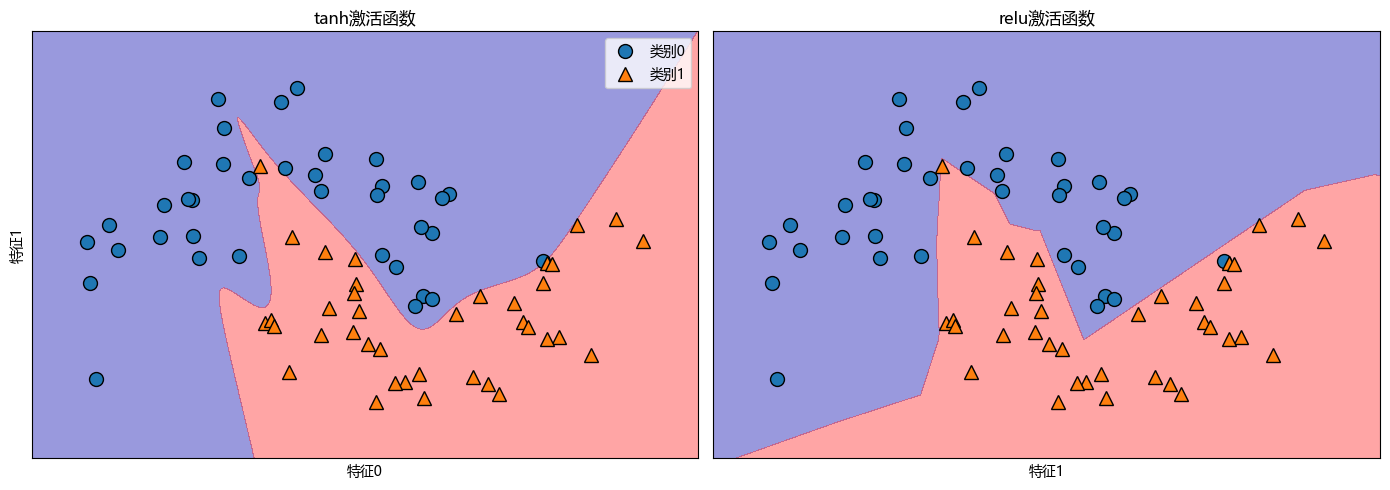

In [10]:
mlp_tanh = MLPClassifier(solver='lbfgs',random_state=0,
                         hidden_layer_sizes=[10,10],activation='tanh')
mlp_tanh.fit(X_train,y_train)

mlp_relu = MLPClassifier(solver='lbfgs',random_state=0,
                         hidden_layer_sizes=[10,10],activation='relu')
mlp_relu.fit(X_train,y_train)

print("="*50)
print("不同激活函数的对比")
print("="*50)
print(f"tanh激活函数 - 测试集准确率：{mlp_tanh.score(X_test,y_test):.3f}")
print(f"relu激活函数 - 测试集准确率：{mlp_relu.score(X_test,y_test):.3f}")

fig,axes = plt.subplots(1,2,figsize=(14,5))

mglearn.plots.plot_2d_separator(mlp_tanh,X_train,fill=True,alpha=0.4,ax=axes[0])
mglearn.discrete_scatter(X_train[:,0],X_train[:,1],y_train,ax=axes[0])
axes[0].set_title("tanh激活函数")
axes[0].set_xlabel("特征0")
axes[0].set_ylabel("特征1")

mglearn.plots.plot_2d_separator(mlp_relu,X_train,fill=True,alpha=0.4,ax=axes[1])
mglearn.discrete_scatter(X_train[:,0],X_train[:,1],y_train,ax=axes[1])
axes[1].set_title("relu激活函数")
axes[1].set_xlabel("特征0")
axes[1].set_xlabel("特征1")

axes[0].legend(["类别0","类别1"],loc="best")
plt.tight_layout()
plt.show()